<a href="https://colab.research.google.com/github/kavenlankalapalli/Capstone-DR/blob/main/DRModel_EfficientNetB0_B3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras

Filtered by existing images: 3662 -> 3662 rows
Saved: /content/cleaned_labels.csv


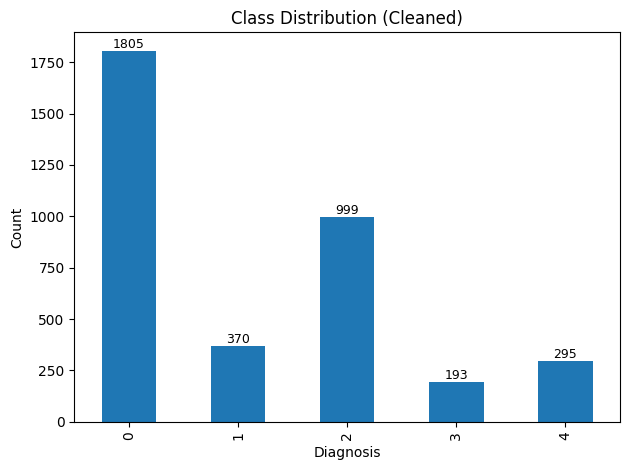

In [9]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ----  These paths can be edited depending on the location where images are stored ----
CSV_PATH = Path("/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/train.csv")
IMG_DIR  = Path("/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/train_images")
OUT_CSV  = Path("cleaned_labels.csv")
# --------------------------

# 1) Basic path checks
assert CSV_PATH.exists(), f"CSV not found: {CSV_PATH}"
assert IMG_DIR.exists(),  f"Image folder not found: {IMG_DIR}"

# 2) Read CSV and verify schema
try:
    df = pd.read_csv(CSV_PATH)
except Exception as e:
    raise RuntimeError(f"Failed to read CSV: {e}")

required = {"id_code", "diagnosis"}
missing = required - set(df.columns)
assert not missing, f"CSV missing columns: {missing}"

# 3) Clean labels (keep 0..4; drop NaNs)
df["diagnosis"] = pd.to_numeric(df["diagnosis"], errors="coerce")
df = df.dropna(subset=["diagnosis"])
df = df[df["diagnosis"].isin([0,1,2,3,4])].copy()
df["diagnosis"] = df["diagnosis"].astype(int)

# 4) Keep only rows with an existing image file (.png/.jpg/.jpeg)
#    (Simple and fast: list files once, keep stems)
stems = set()
for name in os.listdir(IMG_DIR):
    root, ext = os.path.splitext(name)
    if ext.lower() in {".png", ".jpg", ".jpeg"}:
        stems.add(root)

before = len(df)
df = df[df["id_code"].astype(str).isin(stems)].copy()
print(f"Filtered by existing images: {before} -> {len(df)} rows")

# 5) Drop duplicate id_code rows
df = df.drop_duplicates(subset="id_code", keep="first")

# 6) Save cleaned labels
df.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV.resolve()}")

# 7) Plot class distribution with counts
ax = df["diagnosis"].value_counts().sort_index().plot(kind="bar", title="Class Distribution (Cleaned)")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


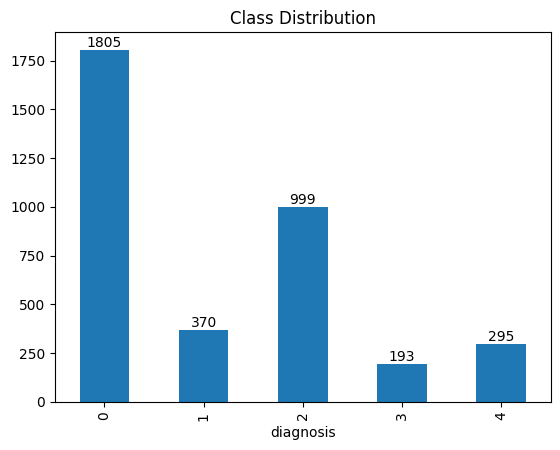

In [10]:
# Load labels CSV
df = pd.read_csv("/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/train.csv")
print(df.head())
df.dropna(subset=["diagnosis"], inplace=True)
df = df[df["diagnosis"].isin([0, 1, 2, 3, 4])]
image_folder = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/train_images"
existing_files = set([f.split(".")[0] for f in os.listdir(image_folder)])

# Filter only rows where image file actually exists
df = df[df["id_code"].isin(existing_files)]
df.drop_duplicates(subset="id_code", keep="first", inplace=True)
df.to_csv("cleaned_labels.csv", index=False)
ax = df["diagnosis"].value_counts().sort_index().plot(kind="bar", title="Class Distribution")

# Add numbers above each bar
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),                     # The value to display
        (p.get_x() + p.get_width() / 2., p.get_height()),  # X and Y coordinates
        ha='center', va='bottom', fontsize=10, color='black'
    )
plt.show()

In [11]:
# file path for our training data labels
csv_path = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/train.csv"

# Read the CSV file into a pandas DataFrame
df_train = pd.read_csv(csv_path)

# Display the first 5 rows of the DataFrame to understand its structure
print("The first 5 rows of our training data:")
df_train.head()

The first 5 rows of our training data:


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [12]:
# Define the path to the directory containing training images
img_path = '/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/train_images'

# Create a new column 'image_path' by joining the image directory path, the id_code, and the .png extension
df_train['image_path'] = df_train['id_code'].apply(lambda x: os.path.join(img_path, x + '.png'))

# Convert the 'diagnosis' column to a string type, so it is treated as a category rather than a number
# This is important for stratified splitting and for many deep learning frameworks when setting up labels for classification
df_train['diagnosis'] = df_train['diagnosis'].astype(str)

# Display the first 5 rows again to see our new 'image_path' column and the updated 'diagnosis' type
print("DataFrame with full image paths and categorical labels:")
df_train.head()

DataFrame with full image paths and categorical labels:


,id_code,diagnosis,image_path
0,000c1434d8d7,2,/content/drive/My Drive/capstone-3/milestone-4...
1,001639a390f0,4,/content/drive/My Drive/capstone-3/milestone-4...
2,0024cdab0c1e,1,/content/drive/My Drive/capstone-3/milestone-4...
3,002c21358ce6,0,/content/drive/My Drive/capstone-3/milestone-4...
4,005b95c28852,0,/content/drive/My Drive/capstone-3/milestone-4...


In [13]:
from sklearn.model_selection import train_test_split

#  used the entire DataFrame for the split, as it contains both the image paths and the labels.
# test_size=0.2 specifies that we want to allocate 20% of the data to the validation set.
# random_state=42 is a seed for the random number generator, ensuring that our split is reproducible.
# stratify=df_train['diagnosis'] is the key parameter that ensures both training and validation sets
# have the same proportion of samples for each diagnosis class.

train_df, val_df = train_test_split(
    df_train,
    test_size=0.2,
    random_state=42,
    stratify=df_train['diagnosis']
)

# Reset the index of the new dataframes to avoid potential issues later
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# --- Verification ---
# Print the number of images in each new dataframe
print(f"Total original images: {len(df_train)}")
print(f"Number of images in the new training set: {len(train_df)}")
print(f"Number of images in the new validation set: {len(val_df)}")
print("-" * 50)

# Verify the distribution in the training set by checking the percentage of each class
print("Distribution of diagnoses in the training set (%):")
print(train_df['diagnosis'].value_counts(normalize=True).sort_index() * 100)
print("-" * 50)

# Verify the distribution in the validation set
print("Distribution of diagnoses in the validation set (%):")
print(val_df['diagnosis'].value_counts(normalize=True).sort_index() * 100)

Total original images: 3662
Number of images in the new training set: 2929
Number of images in the new validation set: 733
--------------------------------------------------
Distribution of diagnoses in the training set (%):
diagnosis
0    49.300102
1    10.105838
2    27.278935
3     5.257767
4     8.057357
Name: proportion, dtype: float64
--------------------------------------------------
Distribution of diagnoses in the validation set (%):
diagnosis
0    49.249659
1    10.095498
2    27.285130
3     5.320600
4     8.049113
Name: proportion, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split
import numpy as np

#  used the entire DataFrame for the split, as it contains both the image paths and the labels.
# test_size=0.2 specifies that we want to allocate 20% of the data to the validation set.
# random_state=42 is a seed for the random number generator, ensuring that our split is reproducible.
# stratify=df_train['diagnosis'] is the key parameter that ensures both training and validation sets
# have the same proportion of samples for each diagnosis class.


TEST_SIZE = 0.20
SEED = 42

# Must-have checks
assert "diagnosis" in df_train.columns, "df_train is missing 'diagnosis'"
assert len(df_train) > 0, "df_train is empty"
assert df_train["diagnosis"].notna().all(), "Found NaNs in 'diagnosis'"

# Is stratification feasible? (each class must have at least 1 sample in BOTH splits)
vc = df_train["diagnosis"].value_counts()
can_stratify = (vc.min() >= 2) and ((vc * TEST_SIZE).astype(int).min() >= 1) and ((vc * (1 - TEST_SIZE)).astype(int).min() >= 1)

strat_target = df_train["diagnosis"] if can_stratify else None
if not can_stratify:
    print(" Some classes too small for a stratified 80/20 split — falling back to random split.")

train_df, val_df = train_test_split(
    df_train,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=strat_target
)

# Basic sanity
assert len(train_df) > 0 and len(val_df) > 0, "Empty train/val after split — adjust TEST_SIZE or data."

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# --- Verification ---
print(f"Total original images: {len(df_train)}")
print(f"Number of images in the new training set: {len(train_df)}")
print(f"Number of images in the new validation set: {len(val_df)}")
print("-" * 50)
print("Distribution of diagnoses in the training set (%):")
print(train_df['diagnosis'].value_counts(normalize=True).sort_index() * 100)
print("-" * 50)
print("Distribution of diagnoses in the validation set (%):")
print(val_df['diagnosis'].value_counts(normalize=True).sort_index() * 100)

Total original images: 3662
Number of images in the new training set: 2929
Number of images in the new validation set: 733
--------------------------------------------------
Distribution of diagnoses in the training set (%):
diagnosis
0    49.300102
1    10.105838
2    27.278935
3     5.257767
4     8.057357
Name: proportion, dtype: float64
--------------------------------------------------
Distribution of diagnoses in the validation set (%):
diagnosis
0    49.249659
1    10.095498
2    27.285130
3     5.320600
4     8.049113
Name: proportion, dtype: float64


In [15]:
# --- Define Constants ---
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# --- Create a data augmentation layer ---
# This is a modern way to do augmentation directly on the GPU for efficiency
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
], name="data_augmentation")


# --- Function to load and preprocess images ---
# This function will be the core of our pipeline
def load_and_preprocess_image(image_path, label):
    # Read the file from disk
    image = tf.io.read_file(image_path)
    # Decode the image from its compressed format (e.g., PNG)
    image = tf.image.decode_png(image, channels=3)
    # Resize the image to the target dimensions
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    # Normalize pixel values to the [0, 1] range
    image = image / 255.0
    return image, label

# --- Build the Training and Validation Datasets ---
# AUTOTUNE allows tf.data to find the best parallel settings automatically
AUTOTUNE = tf.data.AUTOTUNE

# Create the training dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_df['image_path'], train_df['diagnosis'].astype(int).values))
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(buffer_size=len(train_df)) # Cache and shuffle
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE) # Apply augmentation
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE) # Prefetch the next batch

# Create the validation dataset (no shuffling or augmentation)
val_ds = tf.data.Dataset.from_tensor_slices((val_df['image_path'], val_df['diagnosis'].astype(int).values))
val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.cache() # Cache for faster evaluation
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("tf.data pipelines created successfully.")

tf.data pipelines created successfully.


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import EfficientNetB0
from sklearn.utils import class_weight

# --- 1. Load the Base Model (EfficientNetB0) ---
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# --- 2. Freeze the Base Model ---
# We initially freeze the base model layers. They will not be trained in the first phase.
base_model.trainable = False

# --- 3. Add Custom Layers on Top ---
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(5, activation='softmax')(x)

# --- 4. Create the Final Model ---
model = Model(inputs=base_model.input, outputs=predictions)

# --- 5. Compile the Model with the Correct Loss Function ---
# We use `SparseCategoricalCrossentropy` because our `tf.data` pipeline provides integer labels (0, 1, 2, etc.)
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# --- 6. Print Model Summary ---
print("Model architecture is ready and compiled.")
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model architecture is ready and compiled.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
import tensorflow as tf
from tensorflow.keras import Model, layers, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import backend as K

# --- Config (edit) ---
IMG_HEIGHT, IMG_WIDTH = 224, 224
NUM_CLASSES = 5
LEARNING_RATE = 3e-4

# 0) Basic config assertions (fail fast with clear messages)
assert isinstance(IMG_HEIGHT, int) and isinstance(IMG_WIDTH, int) and IMG_HEIGHT > 0 and IMG_WIDTH > 0, \
    "IMG_HEIGHT/IMG_WIDTH must be positive integers"
assert isinstance(NUM_CLASSES, int) and NUM_CLASSES >= 2, "NUM_CLASSES must be an integer ≥ 2"
assert K.image_data_format() == "channels_last", "This code expects channels_last (NHWC) format"

# 1) Load base model with a safe fallback if ImageNet weights can’t be downloaded
try:
    base_model = EfficientNetB0(weights="imagenet", include_top=False,
                                input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
except Exception as e:
    print(f" Could not load ImageNet weights ({e}). Proceeding with random initialization.")
    base_model = EfficientNetB0(weights=None, include_top=False,
                                input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# 2) Freeze backbone for stage 1
base_model.trainable = False

# 3) Head (compact, regularized)
x = layers.GlobalAveragePooling2D(name="gap")(base_model.output)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4), name="fc")(x)
x = layers.Dropout(0.5, name="dropout")(x)
preds = layers.Dense(NUM_CLASSES, activation="softmax", name="pred")(x)

model = Model(inputs=base_model.input, outputs=preds, name="efficientnetb0_dr")

# 4) Compile with stable optimizer (clip norms helps avoid NaNs)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"])

# 5) Quick forward-pass smoke test (catches shape/dtype issues early)
try:
    _ = model(tf.zeros([1, IMG_HEIGHT, IMG_WIDTH, 3], dtype=tf.float32))
except Exception as e:
    raise RuntimeError("Forward pass failed—check input shape/channels/datatype.") from e

print(" Model built and compiled successfully.")
model.summary()

 Model built and compiled successfully.


Model: "efficientnetb0_dr"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [18]:
# --- 1. Manually Define Class Weights ---
# Based on experimentation, these manually-tuned weights provide a better balance
# for this dataset than the automatic 'balanced' mode.
class_weights_dict = {
    0: 0.75,
    1: 2.0,
    2: 0.8,
    3: 2.8,
    4: 2.5
}
print("Using Manually Adjusted Class Weights:")
print(class_weights_dict)
print("-" * 60)

Using Manually Adjusted Class Weights:
{0: 0.75, 1: 2.0, 2: 0.8, 3: 2.8, 4: 2.5}
------------------------------------------------------------


In [19]:
# --- 2. Define Callbacks for smarter training ---
# EarlyStopping will stop training if val_loss doesn't improve for 5 epochs
# and will restore the best model weights.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ReduceLROnPlateau will reduce the learning rate if the validation loss plateaus.
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

print("Callbacks defined. Starting initial training on the model head...")
print("-" * 60)

Callbacks defined. Starting initial training on the model head...
------------------------------------------------------------


In [20]:
# --- 3. Start Initial Training ---
# The model is trained with the class weights and callbacks.
EPOCHS = 15 # A maximum number of epochs to run

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)

print("\nModel initial training complete.")

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 584s 888ms/step - accuracy: 0.3864 - loss: 1.8886 - val_accuracy: 0.4925 - val_loss: 1.4324 - learning_rate: 3.0000e-04
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.4843 - loss: 1.7992 - val_accuracy: 0.4925 - val_loss: 1.4615 - learning_rate: 3.0000e-04
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.4883 - loss: 1.8122 - val_accuracy: 0.4925 - val_loss: 1.4640 - learning_rate: 3.0000e-04
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.5081 - loss: 1.7901 - val_accuracy: 0.4925 - val_loss: 1.4856 - learning_rate: 3.0000e-04
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.4809 - loss: 1.8219 - val_accuracy: 0.4925 - val_loss: 1.4695 - learning_rate: 6.0000e-05
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.4946 - loss: 1.7948 - val_accuracy: 0.4925 - val_loss: 1.4764 - learning_rate: 6.0000e-05

Model initial training complete.


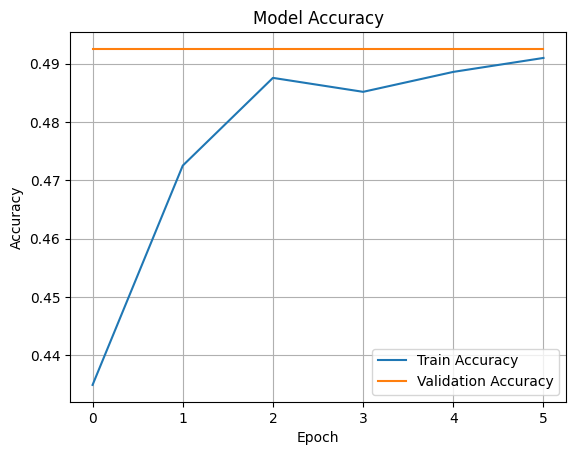

In [21]:
# Plot accuracy and loss
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

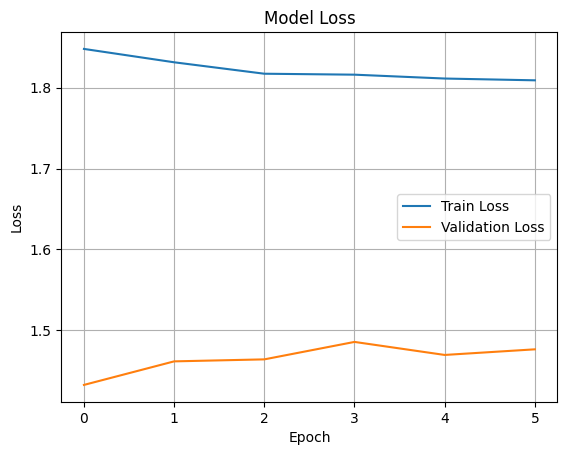

In [22]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step


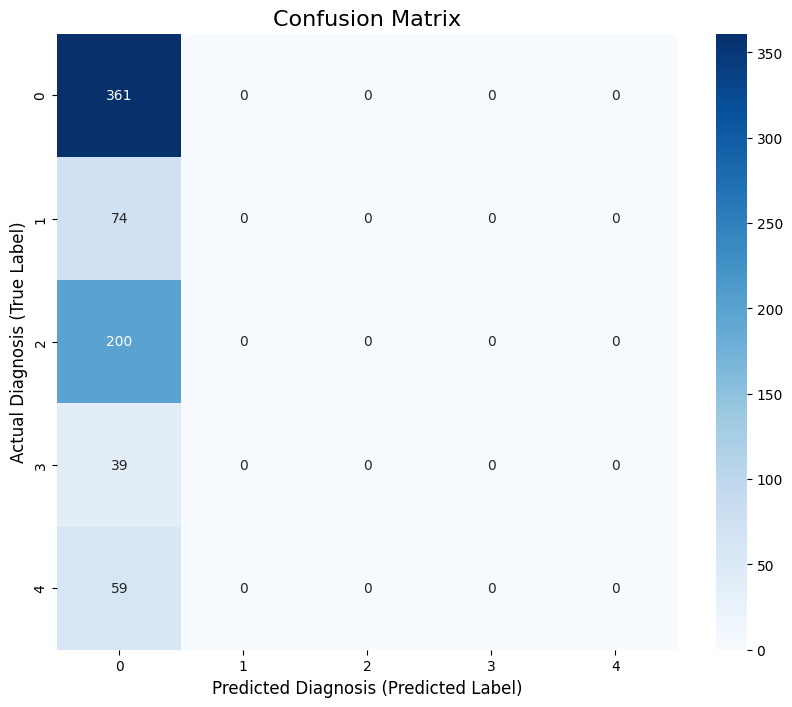


Classification Report:
              precision    recall  f1-score   support

           0       0.49      1.00      0.66       361
           1       0.00      0.00      0.00        74
           2       0.00      0.00      0.00       200
           3       0.00      0.00      0.00        39
           4       0.00      0.00      0.00        59

    accuracy                           0.49       733
   macro avg       0.10      0.20      0.13       733
weighted avg       0.24      0.49      0.33       733



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# --- 1. Get True Labels and Model Predictions ---
val_labels = np.concatenate([y for x, y in val_ds], axis=0)
predictions = model.predict(val_ds)
predicted_labels = np.argmax(predictions, axis=1)

# --- 2. Calculate and Plot the Confusion Matrix ---
class_names = ['0', '1', '2', '3', '4']
cm = confusion_matrix(val_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual Diagnosis (True Label)', fontsize=12)
plt.xlabel('Predicted Diagnosis (Predicted Label)', fontsize=12)
plt.show()

# --- 3. Print the Classification Report ---
print("\nClassification Report:")
print(classification_report(val_labels, predicted_labels, target_names=class_names))


In [24]:

base_model.trainable = True

print(f"Number of layers in the base model: {len(base_model.layers)}")

# --- Optional: Fine-tune only from a certain layer onwards ---
# We freeze the first 100 layers and only fine-tune the rest.
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# --- 2. Re-compile the model with a very low learning rate ---
fine_tune_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=fine_tune_optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# --- 3. Print the model summary again ---
# This will now show a much larger number of trainable parameters.
print("\nModel re-compiled for fine-tuning.")
model.summary()

Number of layers in the base model: 238

Model re-compiled for fine-tuning.


Model: "efficientnetb0_dr"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 4,169,569 (15.91 MB)

 Non-trainable params: 209,223 (817.28 KB)

In [25]:
# --- Continue training the model (fine-tuning) ---

# Define how many additional epochs to train for.
FINE_TUNE_EPOCHS = 15

# Calculate the total number of epochs to run until.
last_epoch = history.epoch[-1]
TOTAL_EPOCHS = last_epoch + 1 + FINE_TUNE_EPOCHS

print(f"Initial training stopped at epoch {last_epoch + 1}.")
print(f"Resuming training for fine-tuning up to epoch {TOTAL_EPOCHS}.")
print("-" * 60)


# Resume training the model.
history_fine_tune = model.fit(
    train_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=last_epoch + 1,
    validation_data=val_ds,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)

# --- Append the fine-tuning history to our original history ---
for key in history_fine_tune.history:
    if key not in history.history:
        history.history[key] = []
    history.history[key].extend(history_fine_tune.history[key])

print("\nModel fine-tuning complete and history has been updated.")

Initial training stopped at epoch 6.
Resuming training for fine-tuning up to epoch 21.
------------------------------------------------------------
Epoch 7/21
92/92 ━━━━━━━━━━━━━━━━━━━━ 93s 480ms/step - accuracy: 0.2222 - loss: 1.9632 - val_accuracy: 0.4925 - val_loss: 1.5244 - learning_rate: 1.0000e-05
Epoch 8/21
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.3678 - loss: 1.8722 - val_accuracy: 0.1037 - val_loss: 1.5823 - learning_rate: 1.0000e-05
Epoch 9/21
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.4029 - loss: 1.8143 - val_accuracy: 0.1010 - val_loss: 1.5692 - learning_rate: 1.0000e-05
Epoch 10/21
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.4088 - loss: 1.7717 - val_accuracy: 0.2729 - val_loss: 1.5368 - learning_rate: 1.0000e-05
Epoch 11/21
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.4481 - loss: 1.7507 - val_accuracy: 0.2906 - val_loss: 1.5145 - learning_rate: 2.0000e-06
Epoch 12/21
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.4364 - 

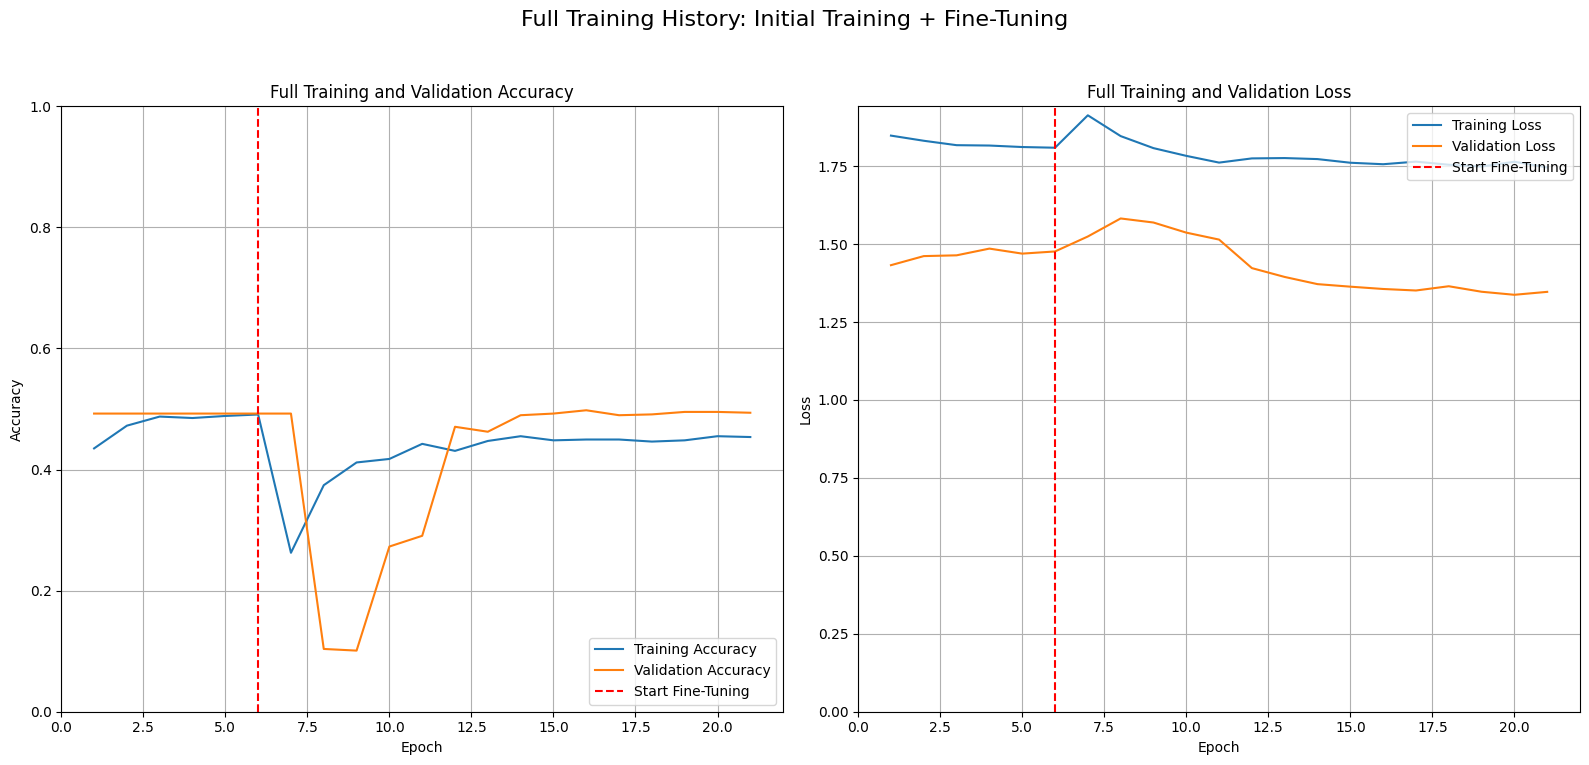

In [27]:
# --- Extract Combined History ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Create a range of epochs for the x-axis
epochs_range = range(1, len(history.history['accuracy']) + 1)

# Determine the epoch where fine-tuning started
initial_epochs_run = len(acc) - len(history_fine_tune.history['accuracy'])


# --- Plotting ---
plt.figure(figsize=(16, 8))

# Subplot 1: Combined Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=initial_epochs_run, color='r', linestyle='--', label='Start Fine-Tuning')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Full Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Subplot 2: Combined Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=initial_epochs_run, color='r', linestyle='--', label='Start Fine-Tuning')
plt.ylim([0, max(plt.ylim())])
plt.legend(loc='upper right')
plt.title('Full Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.suptitle('Full Training History: Initial Training + Fine-Tuning', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 317ms/step


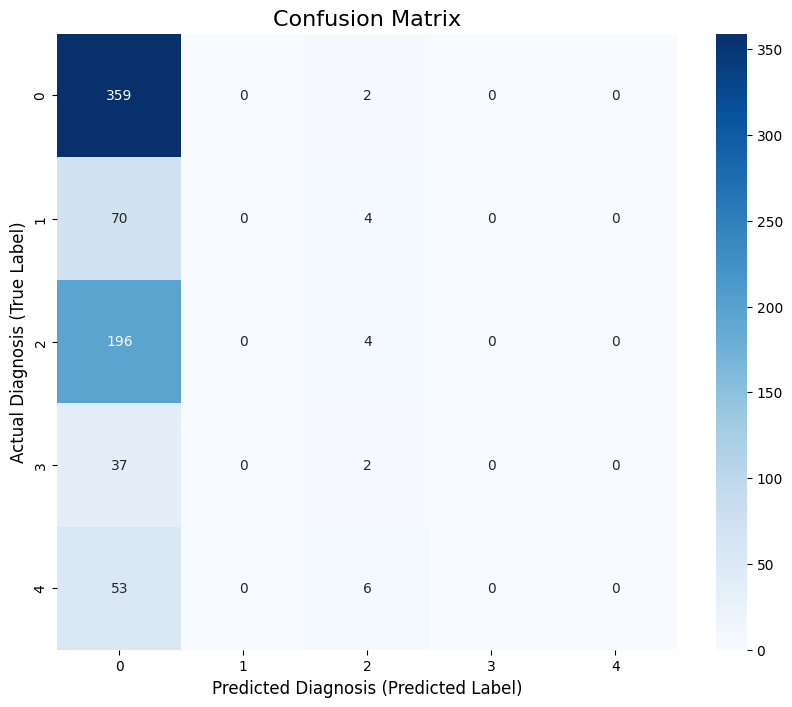


Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.99      0.67       361
           1       0.00      0.00      0.00        74
           2       0.22      0.02      0.04       200
           3       0.00      0.00      0.00        39
           4       0.00      0.00      0.00        59

    accuracy                           0.50       733
   macro avg       0.14      0.20      0.14       733
weighted avg       0.31      0.50      0.34       733



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# --- 1. Get True Labels and Model Predictions ---
val_labels = np.concatenate([y for x, y in val_ds], axis=0)
predictions = model.predict(val_ds)
predicted_labels = np.argmax(predictions, axis=1)

# --- 2. Calculate and Plot the Confusion Matrix ---
class_names = ['0', '1', '2', '3', '4']
cm = confusion_matrix(val_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual Diagnosis (True Label)', fontsize=12)
plt.xlabel('Predicted Diagnosis (Predicted Label)', fontsize=12)
plt.show()

# --- 3. Print the Classification Report ---
print("\nClassification Report:")
print(classification_report(val_labels, predicted_labels, target_names=class_names))


In [29]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import EfficientNetB3
from sklearn.utils import class_weight

# --- 1. Load the Base Model (EfficientNetB3) ---
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# --- 2. Freeze the Base Model ---
# We initially freeze the base model layers. They will not be trained in the first phase.
base_model.trainable = False

# --- 3. Add Custom Layers on Top ---
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(5, activation='softmax')(x)

# --- 4. Create the Final Model ---
model = Model(inputs=base_model.input, outputs=predictions)

# --- 5. Compile the Model with the Correct Loss Function ---
# We use `SparseCategoricalCrossentropy` because our `tf.data` pipeline provides integer labels (0, 1, 2, etc.)
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# --- 6. Print Model Summary ---
print("Model architecture is ready and compiled.")
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model architecture is ready and compiled.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,178,292 (42.64 MB)

 Trainable params: 394,757 (1.51 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [30]:
 # Based on experimentation, these manually-tuned weights provide a better balance
# for this dataset than the automatic 'balanced' mode.
class_weights_dict = {
    0: 0.75,
    1: 2.0,
    2: 0.8,
    3: 2.8,
    4: 2.5
}
print("Using Manually Adjusted Class Weights:")
print(class_weights_dict)
print("-" * 60)

# --- 2. Define Callbacks for smarter training ---
# EarlyStopping will stop training if val_loss doesn't improve for 5 epochs
# and will restore the best model weights.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ReduceLROnPlateau will reduce the learning rate if the validation loss plateaus.
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7
)

print("Callbacks defined. Starting initial training on the model head...")
print("-" * 60)

# --- 3. Start Initial Training ---
# The model is trained with the class weights and callbacks.
EPOCHS = 15 # A maximum number of epochs to run

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)

print("\nModel initial training complete.")

Using Manually Adjusted Class Weights:
{0: 0.75, 1: 2.0, 2: 0.8, 3: 2.8, 4: 2.5}
------------------------------------------------------------
Callbacks defined. Starting initial training on the model head...
------------------------------------------------------------
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 110s 716ms/step - accuracy: 0.3919 - loss: 1.8638 - val_accuracy: 0.4925 - val_loss: 1.4730 - learning_rate: 0.0010
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.4884 - loss: 1.7888 - val_accuracy: 0.4925 - val_loss: 1.4242 - learning_rate: 0.0010
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.4779 - loss: 1.8164 - val_accuracy: 0.4925 - val_loss: 1.4623 - learning_rate: 0.0010
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.4969 - loss: 1.7905 - val_accuracy: 0.4925 - val_loss: 1.4544 - learning_rate: 0.0010
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.4940 - loss: 1.7735 - val_accuracy: 0.4925 - val_loss: 1.44

In [31]:
# --- 1. Unfreeze the base model ---
base_model.trainable = True

print(f"Number of layers in the base model: {len(base_model.layers)}")

# --- Optional: Fine-tune only from a certain layer onwards ---
# We freeze the first 100 layers and only fine-tune the rest.
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# --- 2. Re-compile the model with a very low learning rate ---
fine_tune_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=fine_tune_optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# --- 3. Print the model summary again ---
# This will now show a much larger number of trainable parameters.
print("\nModel re-compiled for fine-tuning.")
model.summary()

Number of layers in the base model: 385

Model re-compiled for fine-tuning.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,178,292 (42.64 MB)

 Trainable params: 10,970,699 (41.85 MB)

 Non-trainable params: 207,593 (810.91 KB)

In [32]:
# --- Continue training the model (fine-tuning) ---

# Define how many additional epochs to train for.
FINE_TUNE_EPOCHS = 15

# Calculate the total number of epochs to run until.
last_epoch = history.epoch[-1]
TOTAL_EPOCHS = last_epoch + 1 + FINE_TUNE_EPOCHS

print(f"Initial training stopped at epoch {last_epoch + 1}.")
print(f"Resuming training for fine-tuning up to epoch {TOTAL_EPOCHS}.")
print("-" * 60)


# Resume training the model.
history_fine_tune = model.fit(
    train_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=last_epoch + 1,
    validation_data=val_ds,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, reduce_lr]
)

# --- Append the fine-tuning history to our original history ---
for key in history_fine_tune.history:
    if key not in history.history:
        history.history[key] = []
    history.history[key].extend(history_fine_tune.history[key])

print("\nModel fine-tuning complete and history has been updated.")

Initial training stopped at epoch 7.
Resuming training for fine-tuning up to epoch 22.
------------------------------------------------------------
Epoch 8/22
92/92 ━━━━━━━━━━━━━━━━━━━━ 168s 824ms/step - accuracy: 0.1978 - loss: 2.3745 - val_accuracy: 0.4925 - val_loss: 1.4838 - learning_rate: 1.0000e-05
Epoch 9/22
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.3316 - loss: 1.9249 - val_accuracy: 0.4925 - val_loss: 1.5006 - learning_rate: 1.0000e-05
Epoch 10/22
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.4094 - loss: 1.7114 - val_accuracy: 0.3383 - val_loss: 1.5443 - learning_rate: 1.0000e-05
Epoch 11/22
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.4649 - loss: 1.6624 - val_accuracy: 0.5784 - val_loss: 1.3925 - learning_rate: 1.0000e-05
Epoch 12/22
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.4680 - loss: 1.6722 - val_accuracy: 0.6248 - val_loss: 1.2309 - learning_rate: 1.0000e-05
Epoch 13/22
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.4892

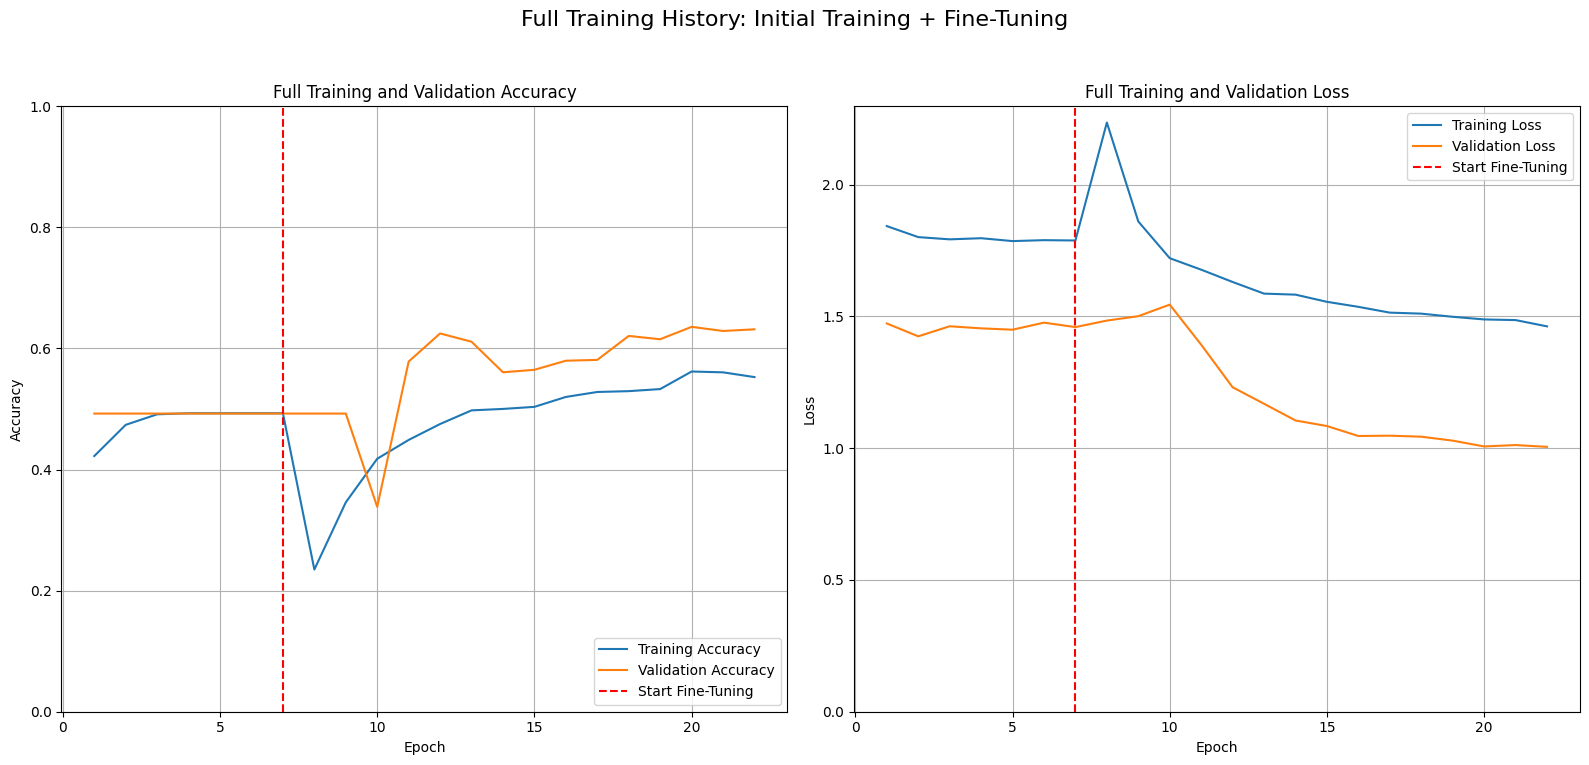

In [33]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Create a range of epochs for the x-axis
epochs_range = range(1, len(history.history['accuracy']) + 1)

# Determine the epoch where fine-tuning started
initial_epochs_run = len(acc) - len(history_fine_tune.history['accuracy'])


# --- Plotting ---
plt.figure(figsize=(16, 8))

# Subplot 1: Combined Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=initial_epochs_run, color='r', linestyle='--', label='Start Fine-Tuning')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Full Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Subplot 2: Combined Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=initial_epochs_run, color='r', linestyle='--', label='Start Fine-Tuning')
plt.ylim([0, max(plt.ylim())])
plt.legend(loc='upper right')
plt.title('Full Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.suptitle('Full Training History: Initial Training + Fine-Tuning', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 498ms/step


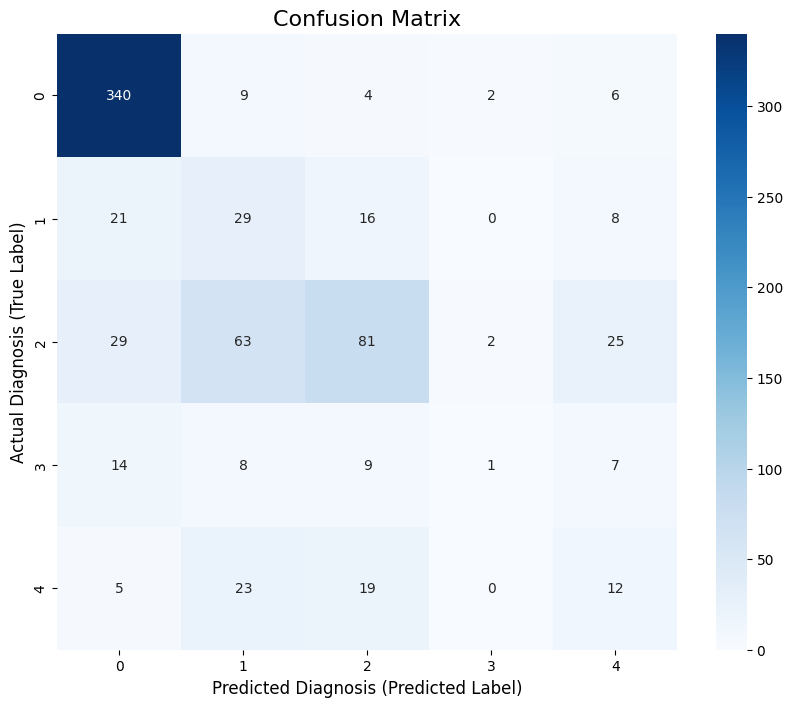


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       361
           1       0.22      0.39      0.28        74
           2       0.63      0.41      0.49       200
           3       0.20      0.03      0.05        39
           4       0.21      0.20      0.21        59

    accuracy                           0.63       733
   macro avg       0.42      0.39      0.38       733
weighted avg       0.63      0.63      0.62       733



In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# --- 1. Get True Labels and Model Predictions ---
val_labels = np.concatenate([y for x, y in val_ds], axis=0)
predictions = model.predict(val_ds)
predicted_labels = np.argmax(predictions, axis=1)

# --- 2. Calculate and Plot the Confusion Matrix ---
class_names = ['0', '1', '2', '3', '4']
cm = confusion_matrix(val_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual Diagnosis (True Label)', fontsize=12)
plt.xlabel('Predicted Diagnosis (Predicted Label)', fontsize=12)
plt.show()

# --- 3. Print the Classification Report ---
print("\nClassification Report:")
print(classification_report(val_labels, predicted_labels, target_names=class_names))

In [35]:
# --- ROC & AUC for Keras models  ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

def _infer_class_names(generator, C):
    # Try to recover class names from a DirectoryIterator / DataFrameIterator
    if hasattr(generator, "class_indices") and isinstance(generator.class_indices, dict):
        inv = {v: k for k, v in generator.class_indices.items()}
        return [inv[i] for i in range(C)]
    return [f"class_{i}" for i in range(C)]

def collect_probs_and_labels(model, generator):
    """
    Returns:
      y_true_cls: (N,) int class ids
      y_proba:    (N,C) probabilities (for binary, C=1)
      class_names: list of class names length C
    """
    # Make order deterministic
    old_shuffle = getattr(generator, "shuffle", None)
    try:
        generator.shuffle = False
    except Exception:
        pass
    try:
        generator.reset()
    except Exception:
        pass

    # Predict probabilities for all samples
    y_proba = model.predict(generator, verbose=0)

    # Get ground-truth labels
    if hasattr(generator, "classes"):
        y_true_cls = np.asarray(generator.classes, dtype=int)
        C = y_proba.shape[1] if y_proba.ndim == 2 else 1
        class_names = _infer_class_names(generator, C)
    else:
        # Fallback: read labels batch-by-batch
        y_true = []
        for i in range(len(generator)):
            _, yb = generator[i]
            if yb.ndim > 1 and yb.shape[-1] > 1:   # one-hot
                y_true.extend(np.argmax(yb, axis=1))
            else:                                  # sparse / binary
                y_true.extend(np.asarray(yb).ravel().astype(int))
        y_true_cls = np.asarray(y_true, dtype=int)
        C = y_proba.shape[1] if y_proba.ndim == 2 else 1
        class_names = _infer_class_names(generator, C)

    # Restore shuffle setting if possible
    if old_shuffle is not None:
        try:
            generator.shuffle = old_shuffle
        except Exception:
            pass

    # Ensure 2D probs (N, C)
    if y_proba.ndim == 1:
        y_proba = y_proba[:, None]
    return y_true_cls, y_proba, class_names

def plot_roc_auc(y_true_cls, y_proba, class_names=None, title_suffix=""):
    """
    Auto-detects binary vs multiclass and plots ROC(s).
    Prints AUC summary (per-class + micro/macro for multiclass; single AUC for binary).
    """
    y_true_cls = np.asarray(y_true_cls, dtype=int)
    if y_proba.ndim == 1:
        y_proba = y_proba[:, None]
    N, C = y_proba.shape
    if class_names is None:
        class_names = [f"class_{i}" for i in range(C)]

    if C == 1:
        # --- Binary case ---
        y_score = np.squeeze(y_proba)  # (N,)
        auc = roc_auc_score(y_true_cls, y_score)
        fpr, tpr, _ = roc_curve(y_true_cls, y_score)

        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC (binary){title_suffix}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

        print(f"Binary AUC: {auc:.4f}")
        return {"auc": auc}

    else:
        # --- Multiclass (one-vs-rest) ---
        y_true_bin = label_binarize(y_true_cls, classes=list(range(C)))  # (N, C)
        auc_per_class = roc_auc_score(y_true_bin, y_proba, average=None, multi_class="ovr")
        auc_micro = roc_auc_score(y_true_bin, y_proba, average="micro", multi_class="ovr")
        auc_macro = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")

        plt.figure()
        for k in range(C):
            fpr, tpr, _ = roc_curve(y_true_bin[:, k], y_proba[:, k])
            plt.plot(fpr, tpr, label=f"{class_names[k]} (AUC={auc_per_class[k]:.3f})")
        plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC (multiclass one-vs-rest){title_suffix}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

        print("AUC per class:", {class_names[i]: float(auc_per_class[i]) for i in range(C)})
        print(f"AUC micro: {auc_micro:.4f} | AUC macro: {auc_macro:.4f}")
        return {"auc_per_class": auc_per_class, "auc_micro": auc_micro, "auc_macro": auc_macro}

In [39]:
 # Create Data Generators with better augmentation
train_dir = os.path.expanduser("/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/train")
val_dir = os.path.expanduser("/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/validation")
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

In [41]:
val_datagen = ImageDataGenerator(rescale=1./255)
img_size = (224, 224)
batch_size = 32

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    color_mode='rgb',
    class_mode='sparse'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False  # Important for matching predictions to true labels
)


Found 2929 images belonging to 5 classes.
Found 733 images belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


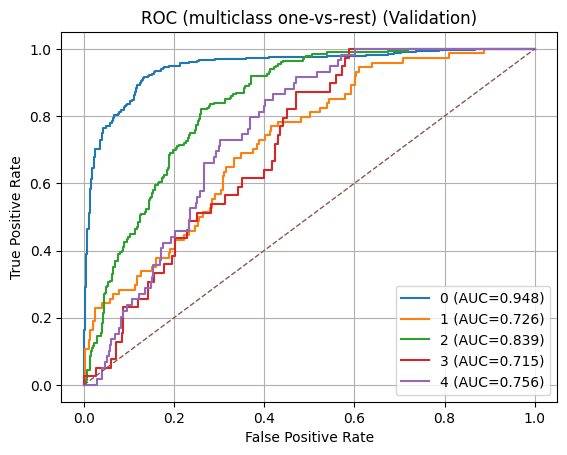

AUC per class: {'0': 0.9480237095284902, '1': 0.7261206578353772, '2': 0.8393527204502814, '3': 0.7146235128944063, '4': 0.7563244983151436}
AUC micro: 0.8818 | AUC macro: 0.7969


In [42]:
y_true_cls, y_proba, class_names = collect_probs_and_labels(model, val_generator)
metrics = plot_roc_auc(y_true_cls, y_proba, class_names, title_suffix=" (Validation)")